# 📐 Analysis After Normalization — 16 Stations
**Data:** `data/normalized/norm_station_{id}.csv`  
**Strategy:** Clip → log1p → Scale (per-station, fit on train split)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({'figure.dpi':120,'font.size':10,'axes.grid':True,'grid.alpha':0.3})

SELECTED_STATIONS = [1,3,4,7,9,12,13,15,16,17,18,24,27,29,31,32]
NORM_DIR = 'data/normalized'
CLEAN_DIR = 'data/clean'

ALL_SCALED = [
    'pm25','pm10','co','o3','no2','so2',
    'temp','rh','dewpt','precip','clouds',
    'wind_spd','wind_gusts','wind_sin','wind_cos',
    'soil_temp_0_7','soil_moist_0_7',
    'oxidation_potential','pollution_load',
    'no2_so2_log_diff','humid_sulfate_risk','dpd',
    'thermal_stability','stagnation_index','dust_source_potential',
]

POLLUTANTS = ['pm25','pm10','co','o3','no2','so2']
WEATHER    = ['temp','rh','dewpt','precip','clouds','wind_spd','wind_gusts']
ENGINEERED = ['oxidation_potential','pollution_load','no2_so2_log_diff',
              'humid_sulfate_risk','dpd','thermal_stability',
              'stagnation_index','dust_source_potential']

norm_dfs  = []
norm_meta = []
for sid in SELECTED_STATIONS:
    df = pd.read_csv(f'{NORM_DIR}/norm_station_{sid}.csv', parse_dates=['timestamp'])
    df = df.set_index('timestamp').sort_index()
    norm_dfs.append(df)
    norm_meta.append({'station_id':sid,
                       'province':df['province'].iloc[0],
                       'district':df['district'].iloc[0]})

_sid2i = {m['station_id']:i for i,m in enumerate(norm_meta)}
def gdf(sid): return norm_dfs[_sid2i[sid]]

all_norm = pd.concat([df.reset_index() for df in norm_dfs], ignore_index=True)
print(f'Loaded {len(all_norm):,} rows | {len(all_norm.columns)} cols')
all_norm[ALL_SCALED].describe().round(3)

Loaded 408,976 rows | 33 cols


,pm25,pm10,co,o3,no2,so2,temp,rh,dewpt,precip,...,soil_temp_0_7,soil_moist_0_7,oxidation_potential,pollution_load,no2_so2_log_diff,humid_sulfate_risk,dpd,thermal_stability,stagnation_index,dust_source_potential
count,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,...,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000,408976.000
mean,1.184,0.858,0.096,0.054,4.245,0.049,-0.084,0.730,-0.067,0.072,...,-0.115,0.538,0.082,0.120,0.150,0.037,-0.003,0.108,0.277,0.566
std,6.677,4.013,1.082,0.871,23.184,0.701,0.983,0.193,1.015,0.184,...,0.981,0.349,1.012,1.062,1.141,0.727,1.018,0.994,0.156,0.205
min,-1.286,-1.322,-6.408,-2.088,-0.947,-3.428,-3.527,-0.097,-6.301,0.000,...,-3.257,-0.527,-8.940,-3.488,-4.591,-5.937,-1.481,-7.446,-0.048,0.000
25%,-0.407,-0.316,-0.563,-0.526,-0.127,-0.421,-0.785,0.615,-0.612,0.000,...,-0.833,0.237,-0.534,-0.589,-0.607,-0.434,-0.784,-0.421,0.162,0.417
50%,0.053,0.089,-0.141,-0.025,0.081,0.050,-0.121,0.770,0.292,0.000,...,-0.162,0.613,0.134,-0.094,-0.004,0.047,-0.296,0.220,0.243,0.571
75%,0.745,0.757,0.466,0.510,1.109,0.517,0.589,0.886,0.671,0.051,...,0.512,0.854,0.775,0.555,0.749,0.526,0.472,0.760,0.358,0.721
max,56.882,47.968,5.733,15.542,310.630,3.629,3.761,1.014,2.264,1.000,...,4.521,1.018,4.435,5.292,6.180,2.999,7.414,6.157,1.000,1.000


---
## 1. Phân phối sau chuẩn hoá — All Features (Histogram + KDE)

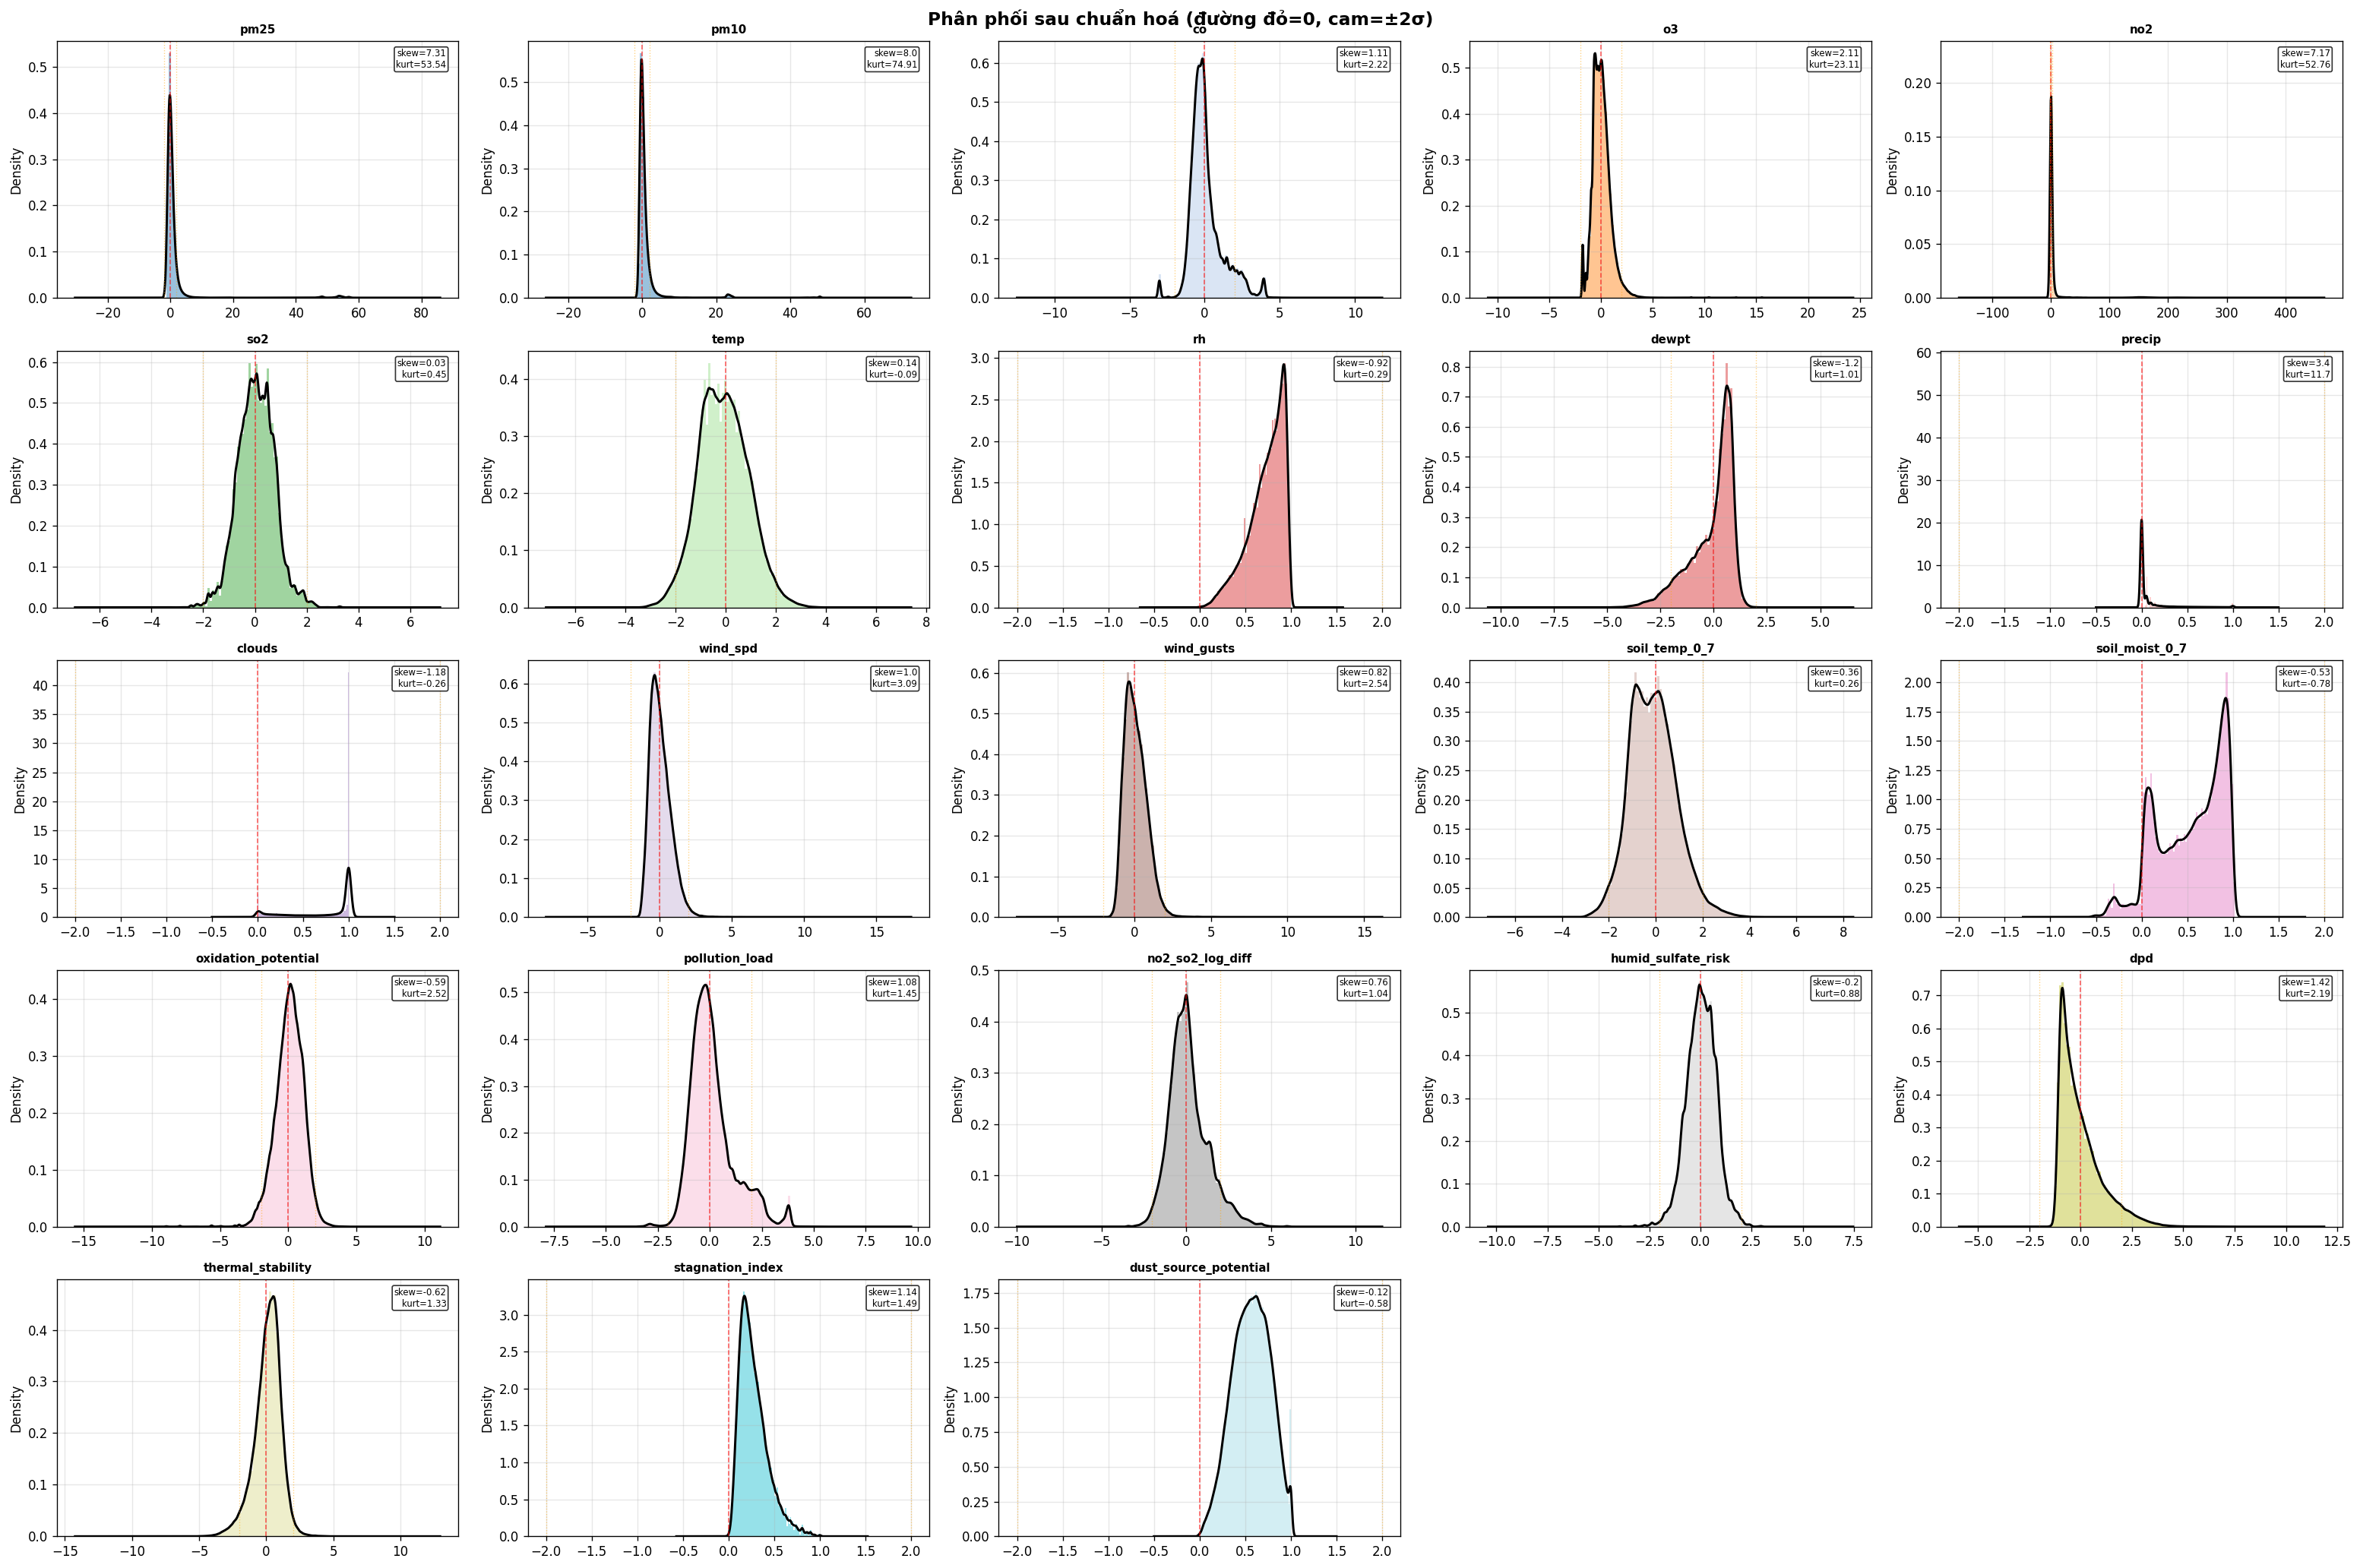

In [6]:
PLOT_COLS = [c for c in ALL_SCALED if c in all_norm.columns and c not in ['wind_sin','wind_cos']]
n = len(PLOT_COLS)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(26, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(PLOT_COLS):
    ax = axes[i]
    vals = all_norm[col].dropna()
    ax.hist(vals, bins=80, density=True, alpha=0.45,
            color=plt.cm.tab20(i/len(PLOT_COLS)), edgecolor='none')
    vals.plot.kde(ax=ax, color='black', lw=1.8)
    ax.axvline(0,  color='red',    lw=1, ls='--', alpha=0.6)
    ax.axvline(-2, color='orange', lw=0.8, ls=':', alpha=0.5)
    ax.axvline(2,  color='orange', lw=0.8, ls=':', alpha=0.5)
    ax.set_title(col, fontsize=9, fontweight='bold')
    sk = round(vals.skew(), 2)
    ku = round(vals.kurt(), 2)
    ax.text(0.97, 0.97, f'skew={sk}\nkurt={ku}',
            transform=ax.transAxes, ha='right', va='top', fontsize=7,
            bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

for j in range(i+1, len(axes)): axes[j].set_visible(False)

fig.suptitle('Phân phối sau chuẩn hoá (đường đỏ=0, cam=±2σ)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('norm_dist_histogram.png', dpi=120, bbox_inches='tight')
plt.show()

## 2. Violin Plot Cross-Station — Pollutants (sau chuẩn hoá)

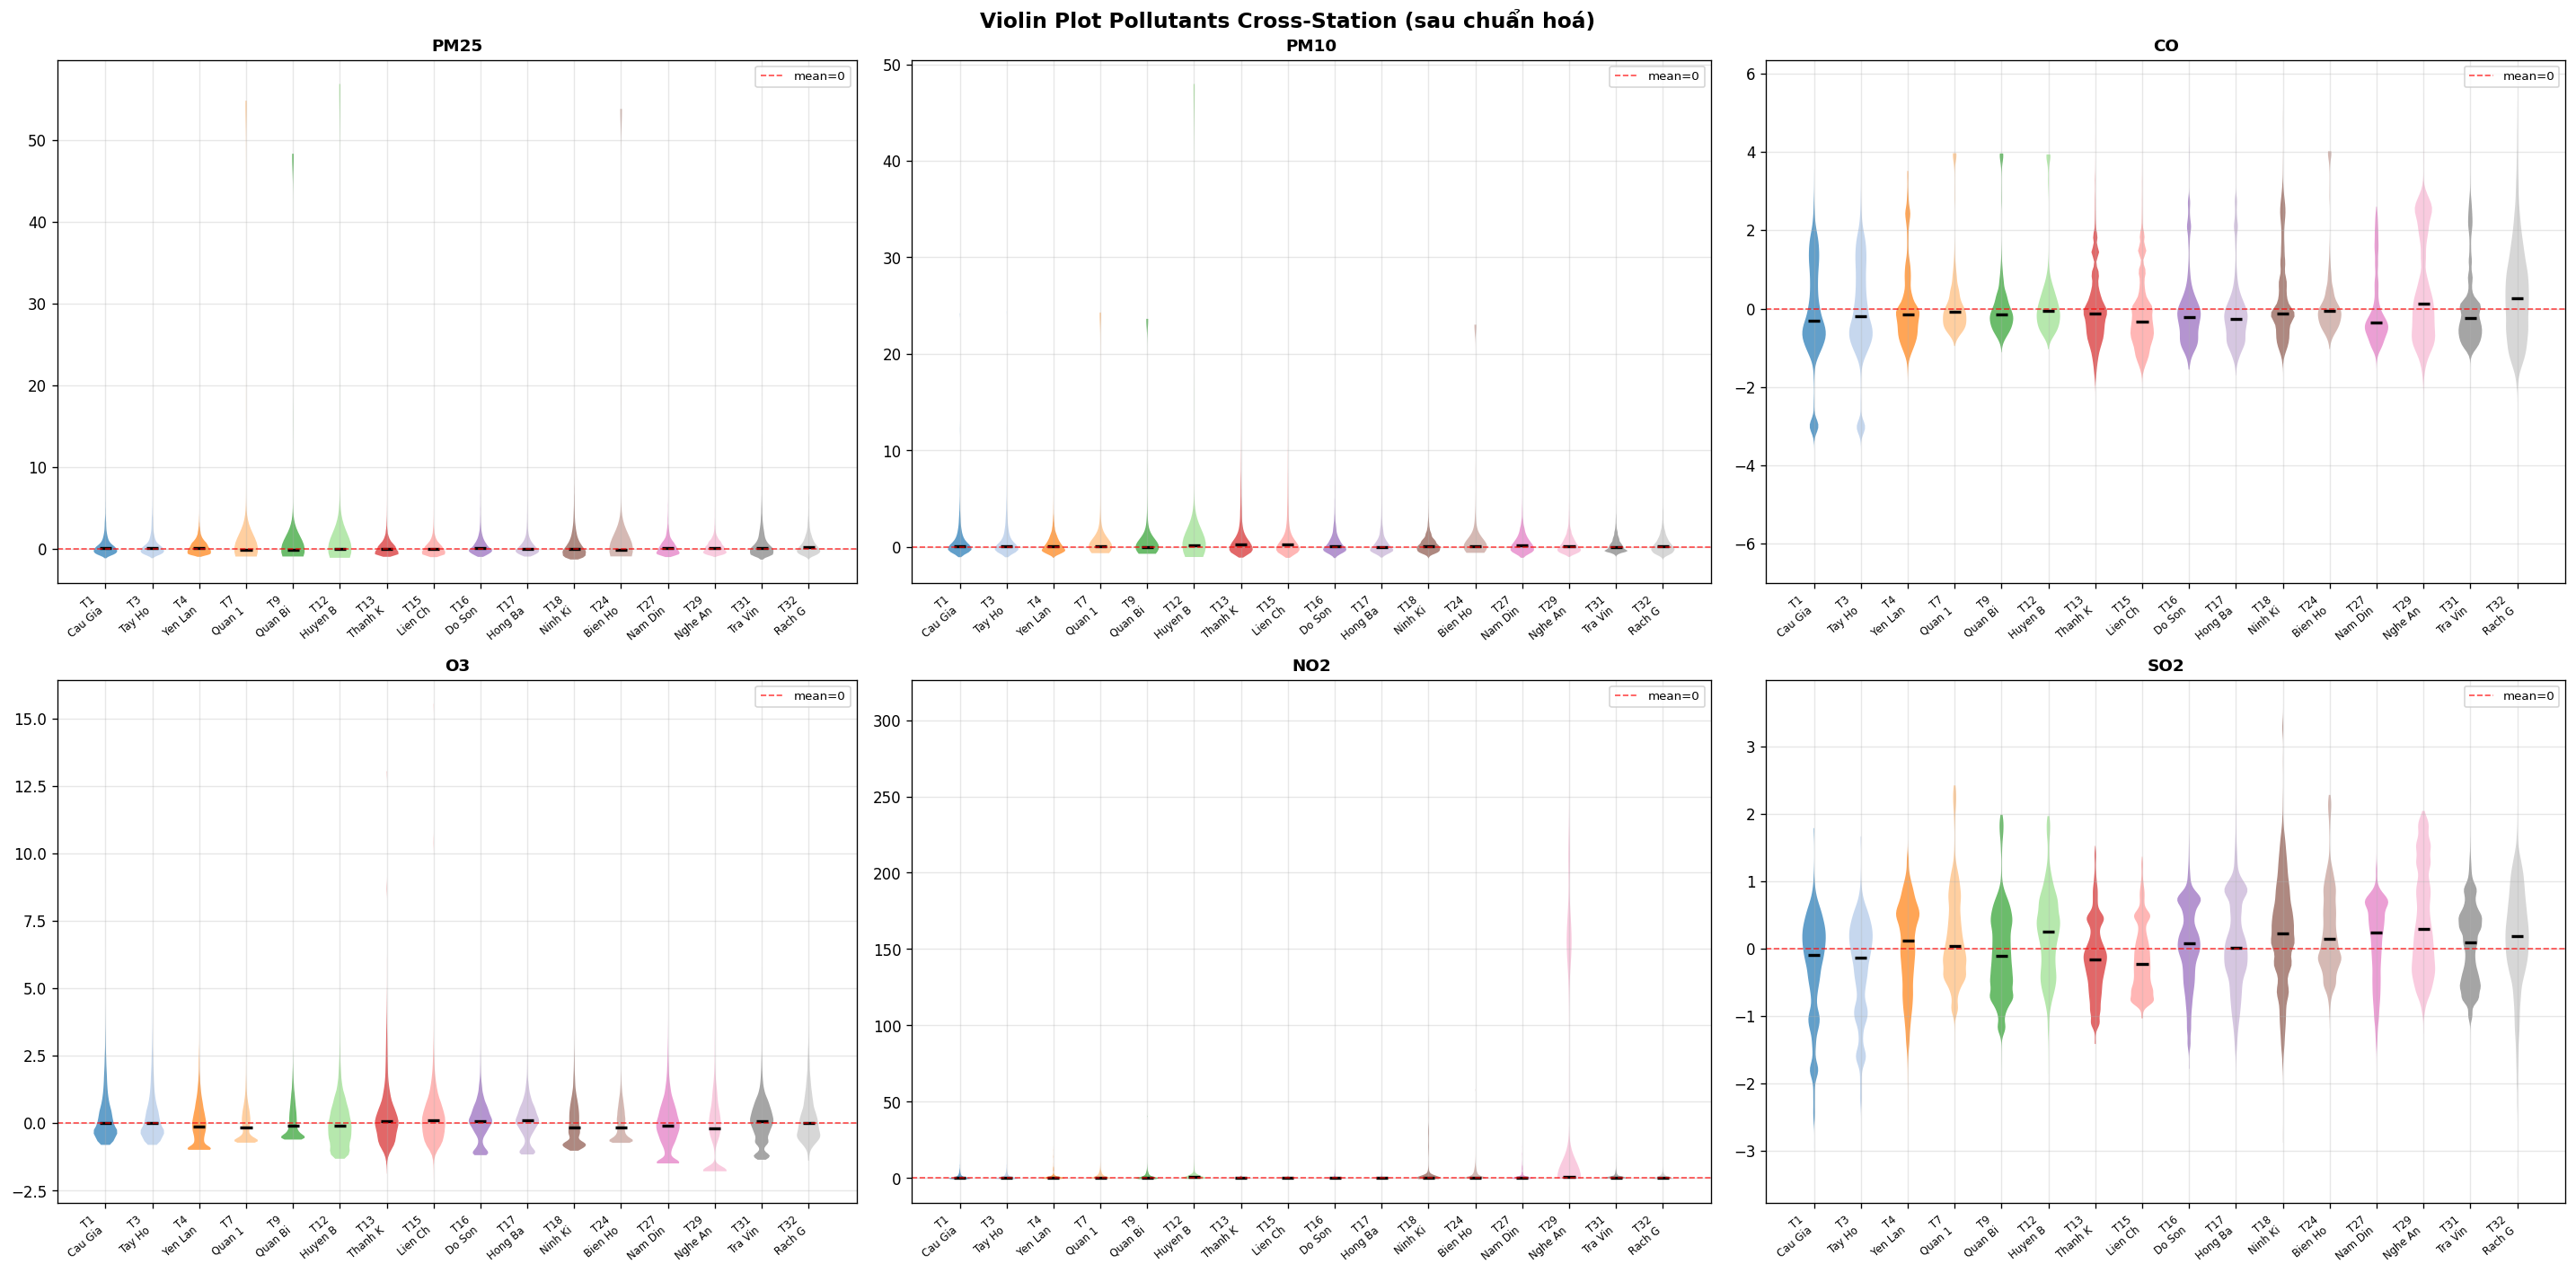

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(24, 12))
axes = axes.flatten()
station_labels = [f"T{m['station_id']}\n{m['district'][:7]}" for m in norm_meta]

for i, col in enumerate(POLLUTANTS):
    ax = axes[i]
    data_list = []
    for df in norm_dfs:
        if col in df.columns:
            data_list.append(df[col].dropna().values)
        else:
            data_list.append(np.array([0]))

    vp = ax.violinplot(data_list, positions=range(len(norm_meta)),
                        showmedians=True, showextrema=False)
    colors = sns.color_palette('tab20', len(norm_meta))
    for body, color in zip(vp['bodies'], colors):
        body.set_facecolor(color); body.set_alpha(0.7)
    vp['cmedians'].set_color('black'); vp['cmedians'].set_linewidth(2)

    ax.axhline(0, color='red', lw=1, ls='--', alpha=0.7, label='mean=0')
    ax.set_xticks(range(len(station_labels)))
    ax.set_xticklabels(station_labels, rotation=40, ha='right', fontsize=7)
    ax.set_title(col.upper(), fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Violin Plot Pollutants Cross-Station (sau chuẩn hoá)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('norm_violin_pollutants.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Boxplot — 8 Engineered Features Cross-Station (sau chuẩn hoá)

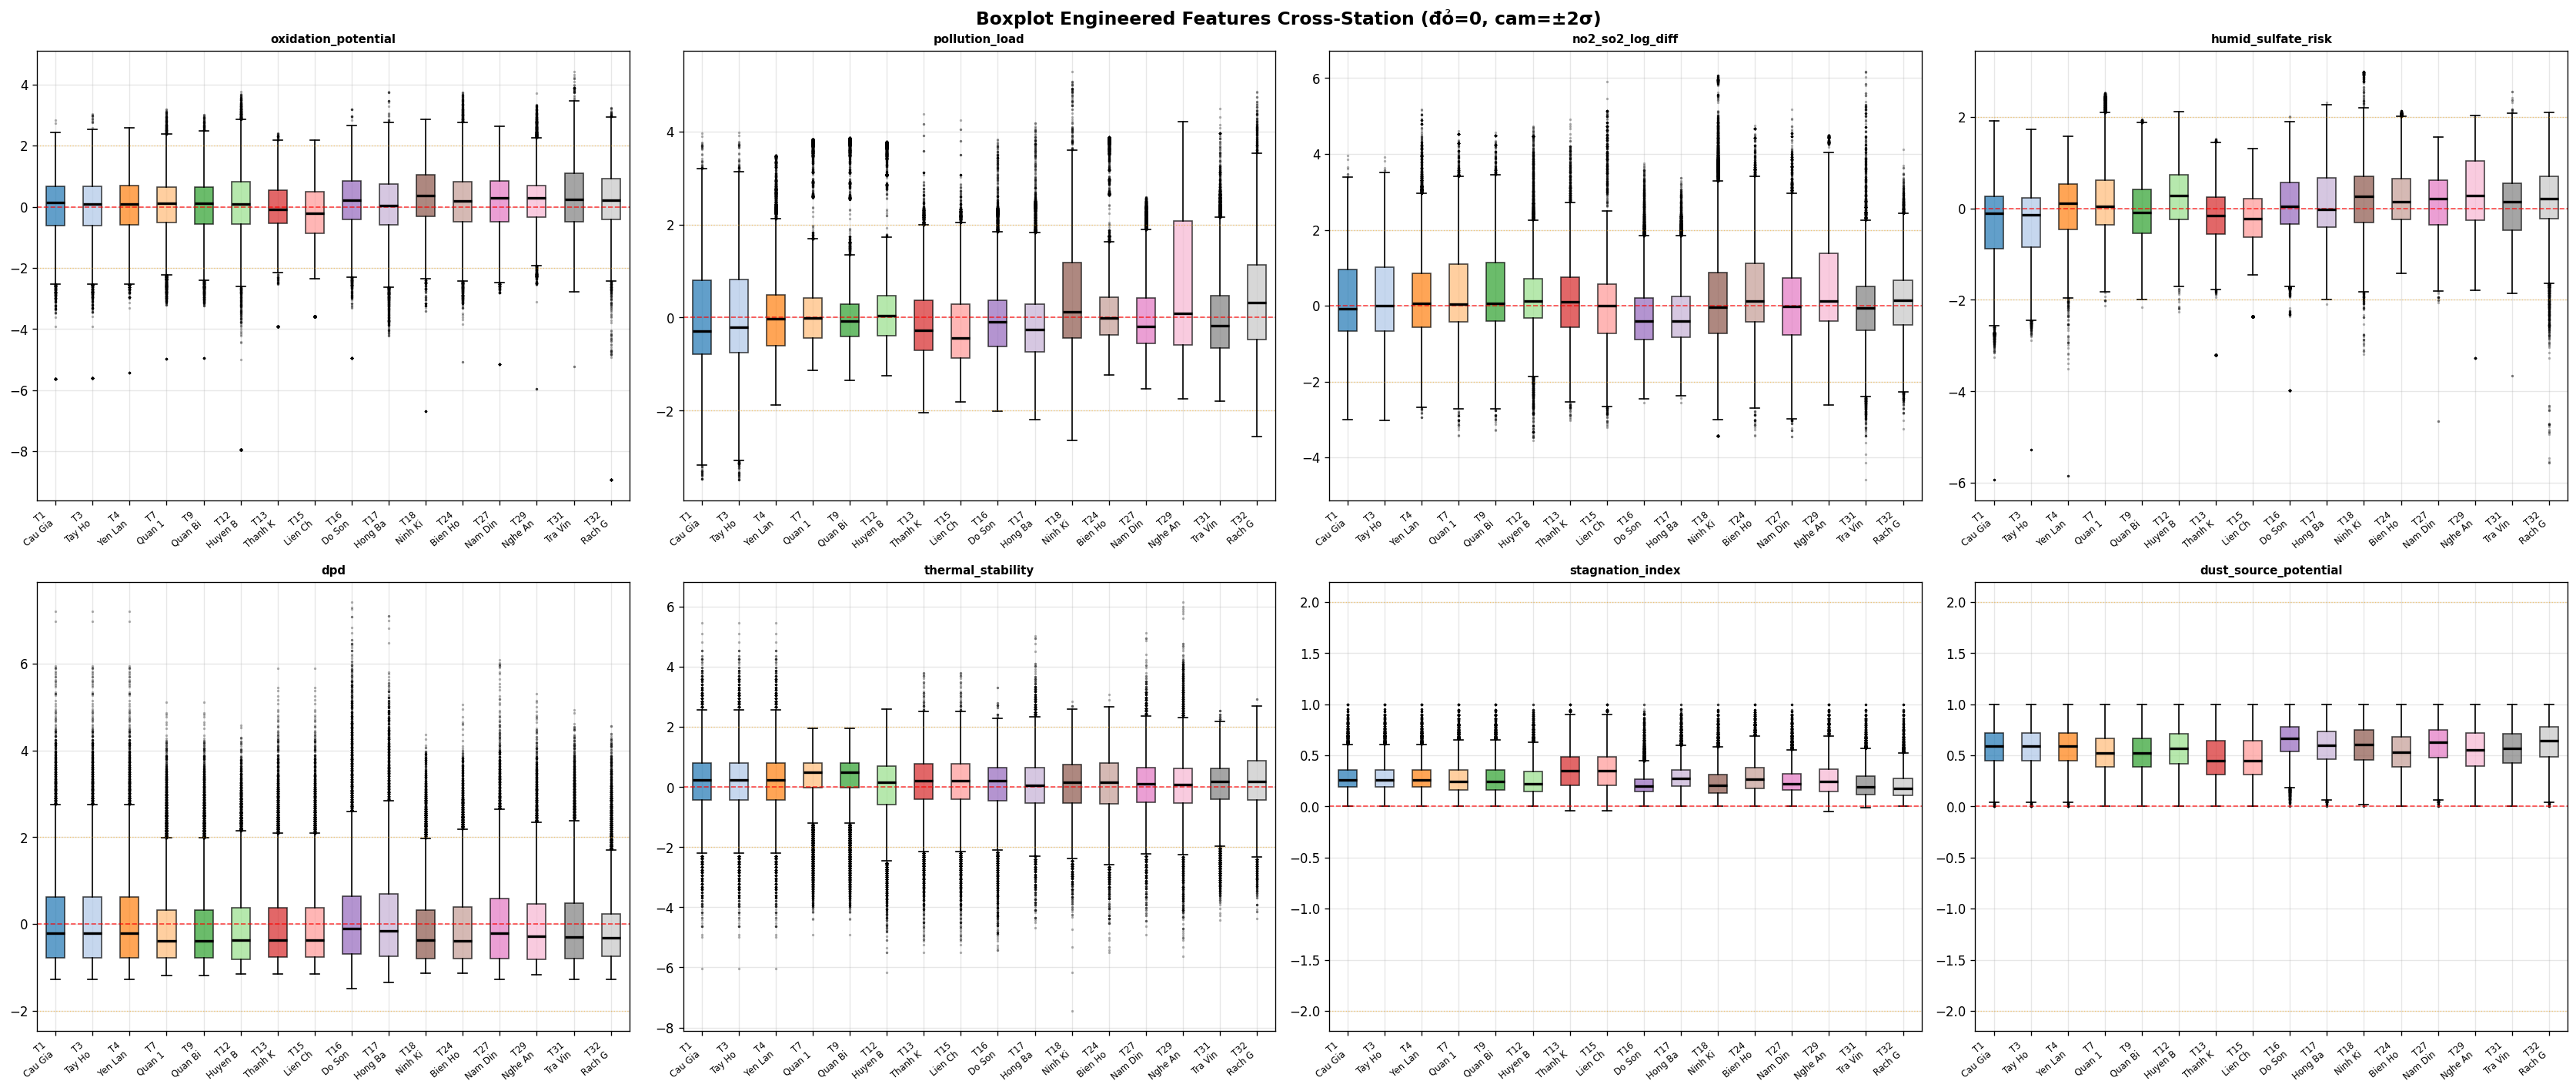

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(28, 12))
axes = axes.flatten()

for i, col in enumerate(ENGINEERED):
    ax = axes[i]
    data_list = [df[col].dropna().values for df in norm_dfs if col in df.columns]

    bp = ax.boxplot(data_list, patch_artist=True, notch=False,
                    medianprops=dict(color='black', lw=2),
                    flierprops=dict(marker='.', markersize=2, alpha=0.3))

    colors = sns.color_palette('tab20', len(norm_meta))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)

    ax.axhline(0,  color='red',    lw=1, ls='--', alpha=0.7)
    ax.axhline(2,  color='orange', lw=0.8, ls=':', alpha=0.5)
    ax.axhline(-2, color='orange', lw=0.8, ls=':', alpha=0.5)
    ax.set_xticks(range(1, len(station_labels)+1))
    ax.set_xticklabels(station_labels, rotation=40, ha='right', fontsize=7)
    ax.set_title(col, fontsize=9, fontweight='bold')

fig.suptitle('Boxplot Engineered Features Cross-Station (đỏ=0, cam=±2σ)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('norm_boxplot_engineered.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Before vs After Normalization — KDE (Trạm 1 & 7 minh hoạ)

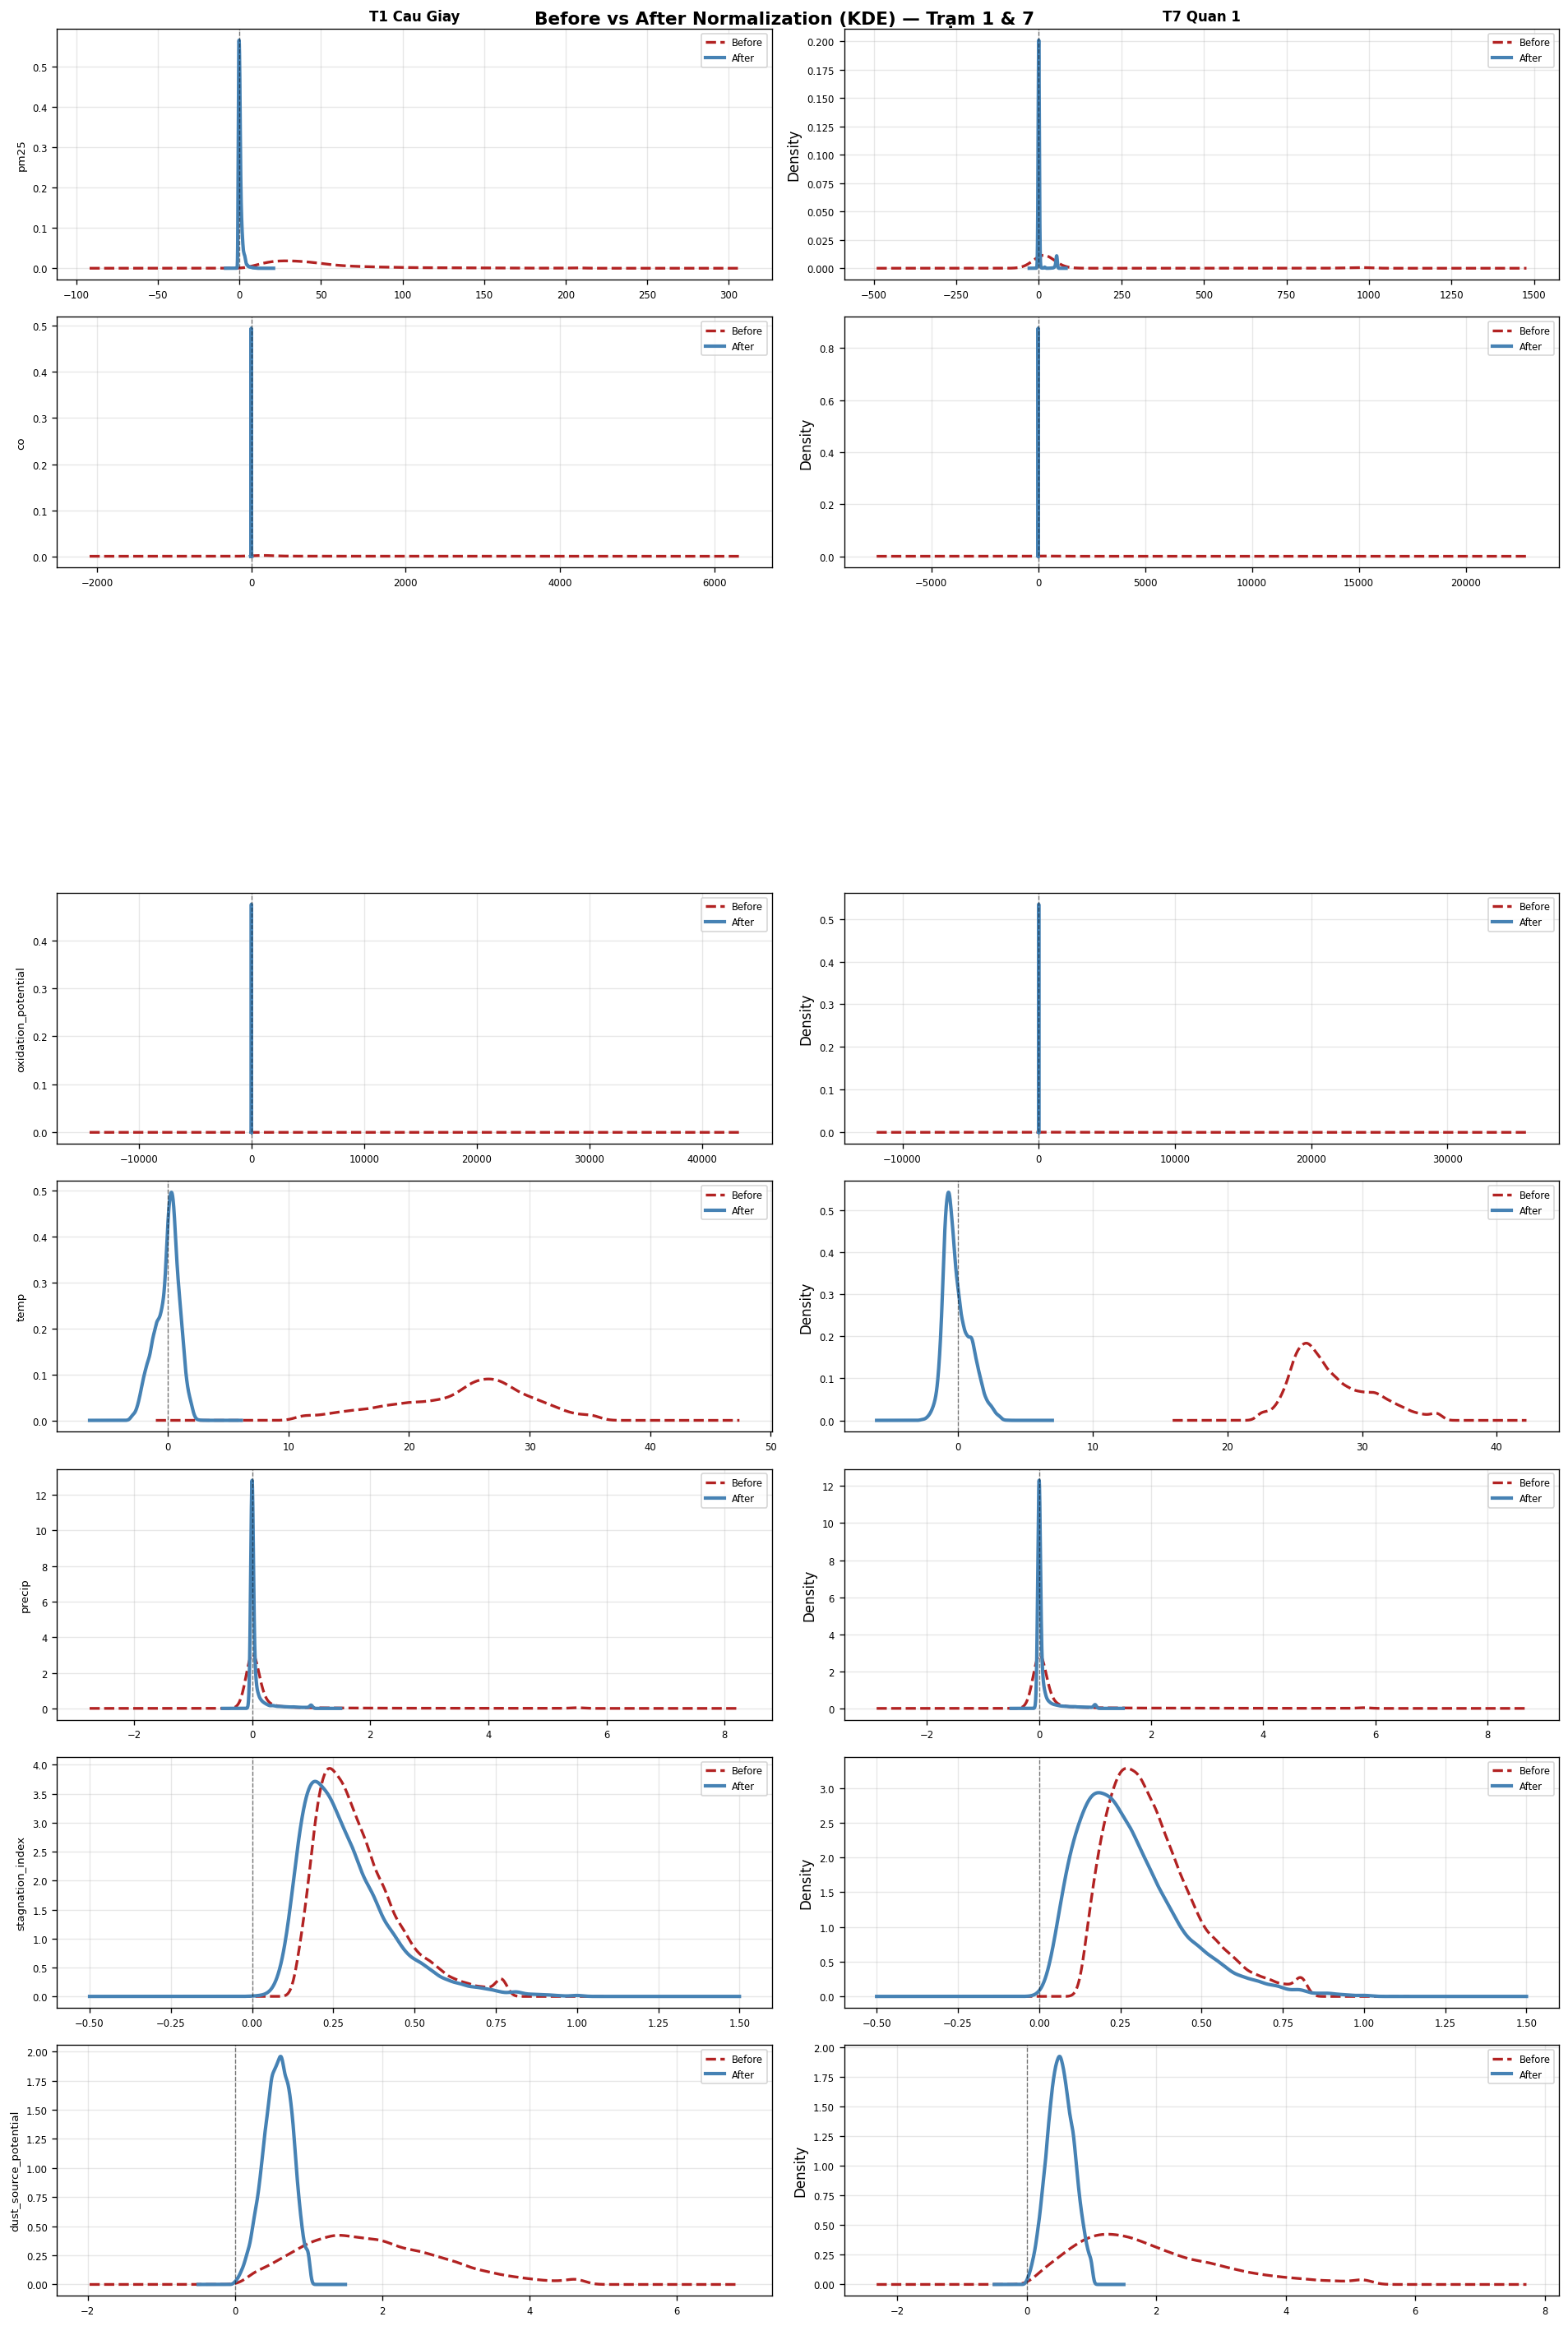

In [9]:
DEMO_SID = [1, 7]   # HN Cau Giay, HCM Q1
DEMO_COLS = ['pm25', 'co', 'no2_so2_ratio', 'oxidation_potential',
             'temp', 'precip', 'stagnation_index', 'dust_source_potential']

fig, axes = plt.subplots(len(DEMO_COLS), len(DEMO_SID), figsize=(16, len(DEMO_COLS)*3))

for col_idx, sid in enumerate(DEMO_SID):
    df_clean = pd.read_csv(f'{CLEAN_DIR}/clean_station_{sid}.csv', parse_dates=['timestamp']).set_index('timestamp')
    df_norm_s = gdf(sid)
    meta = norm_meta[_sid2i[sid]]

    for row_idx, col in enumerate(DEMO_COLS):
        ax = axes[row_idx][col_idx]
        if col not in df_clean.columns or col not in df_norm_s.columns:
            ax.set_visible(False); continue

        raw_vals  = df_clean[col].dropna()
        norm_vals = df_norm_s[col].dropna()

        # Clip raw để KDE không bị kéo quá
        q1r, q99r = raw_vals.quantile(0.01), raw_vals.quantile(0.99)
        raw_vals.clip(q1r, q99r).plot.kde(
            ax=ax, color='firebrick', lw=2, ls='--', label='Before')
        norm_vals.plot.kde(
            ax=ax, color='steelblue', lw=2.5, label='After')

        ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)
        if col_idx == 0:
            ax.set_ylabel(col, fontsize=8)
        if row_idx == 0:
            ax.set_title(f"T{sid} {meta['district']}", fontsize=10, fontweight='bold')
        ax.legend(fontsize=7)
        ax.tick_params(labelsize=7)

fig.suptitle('Before vs After Normalization (KDE) — Trạm 1 & 7',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('norm_before_after_kde.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap (Spearman) — Sau chuẩn hoá (16 Stations)

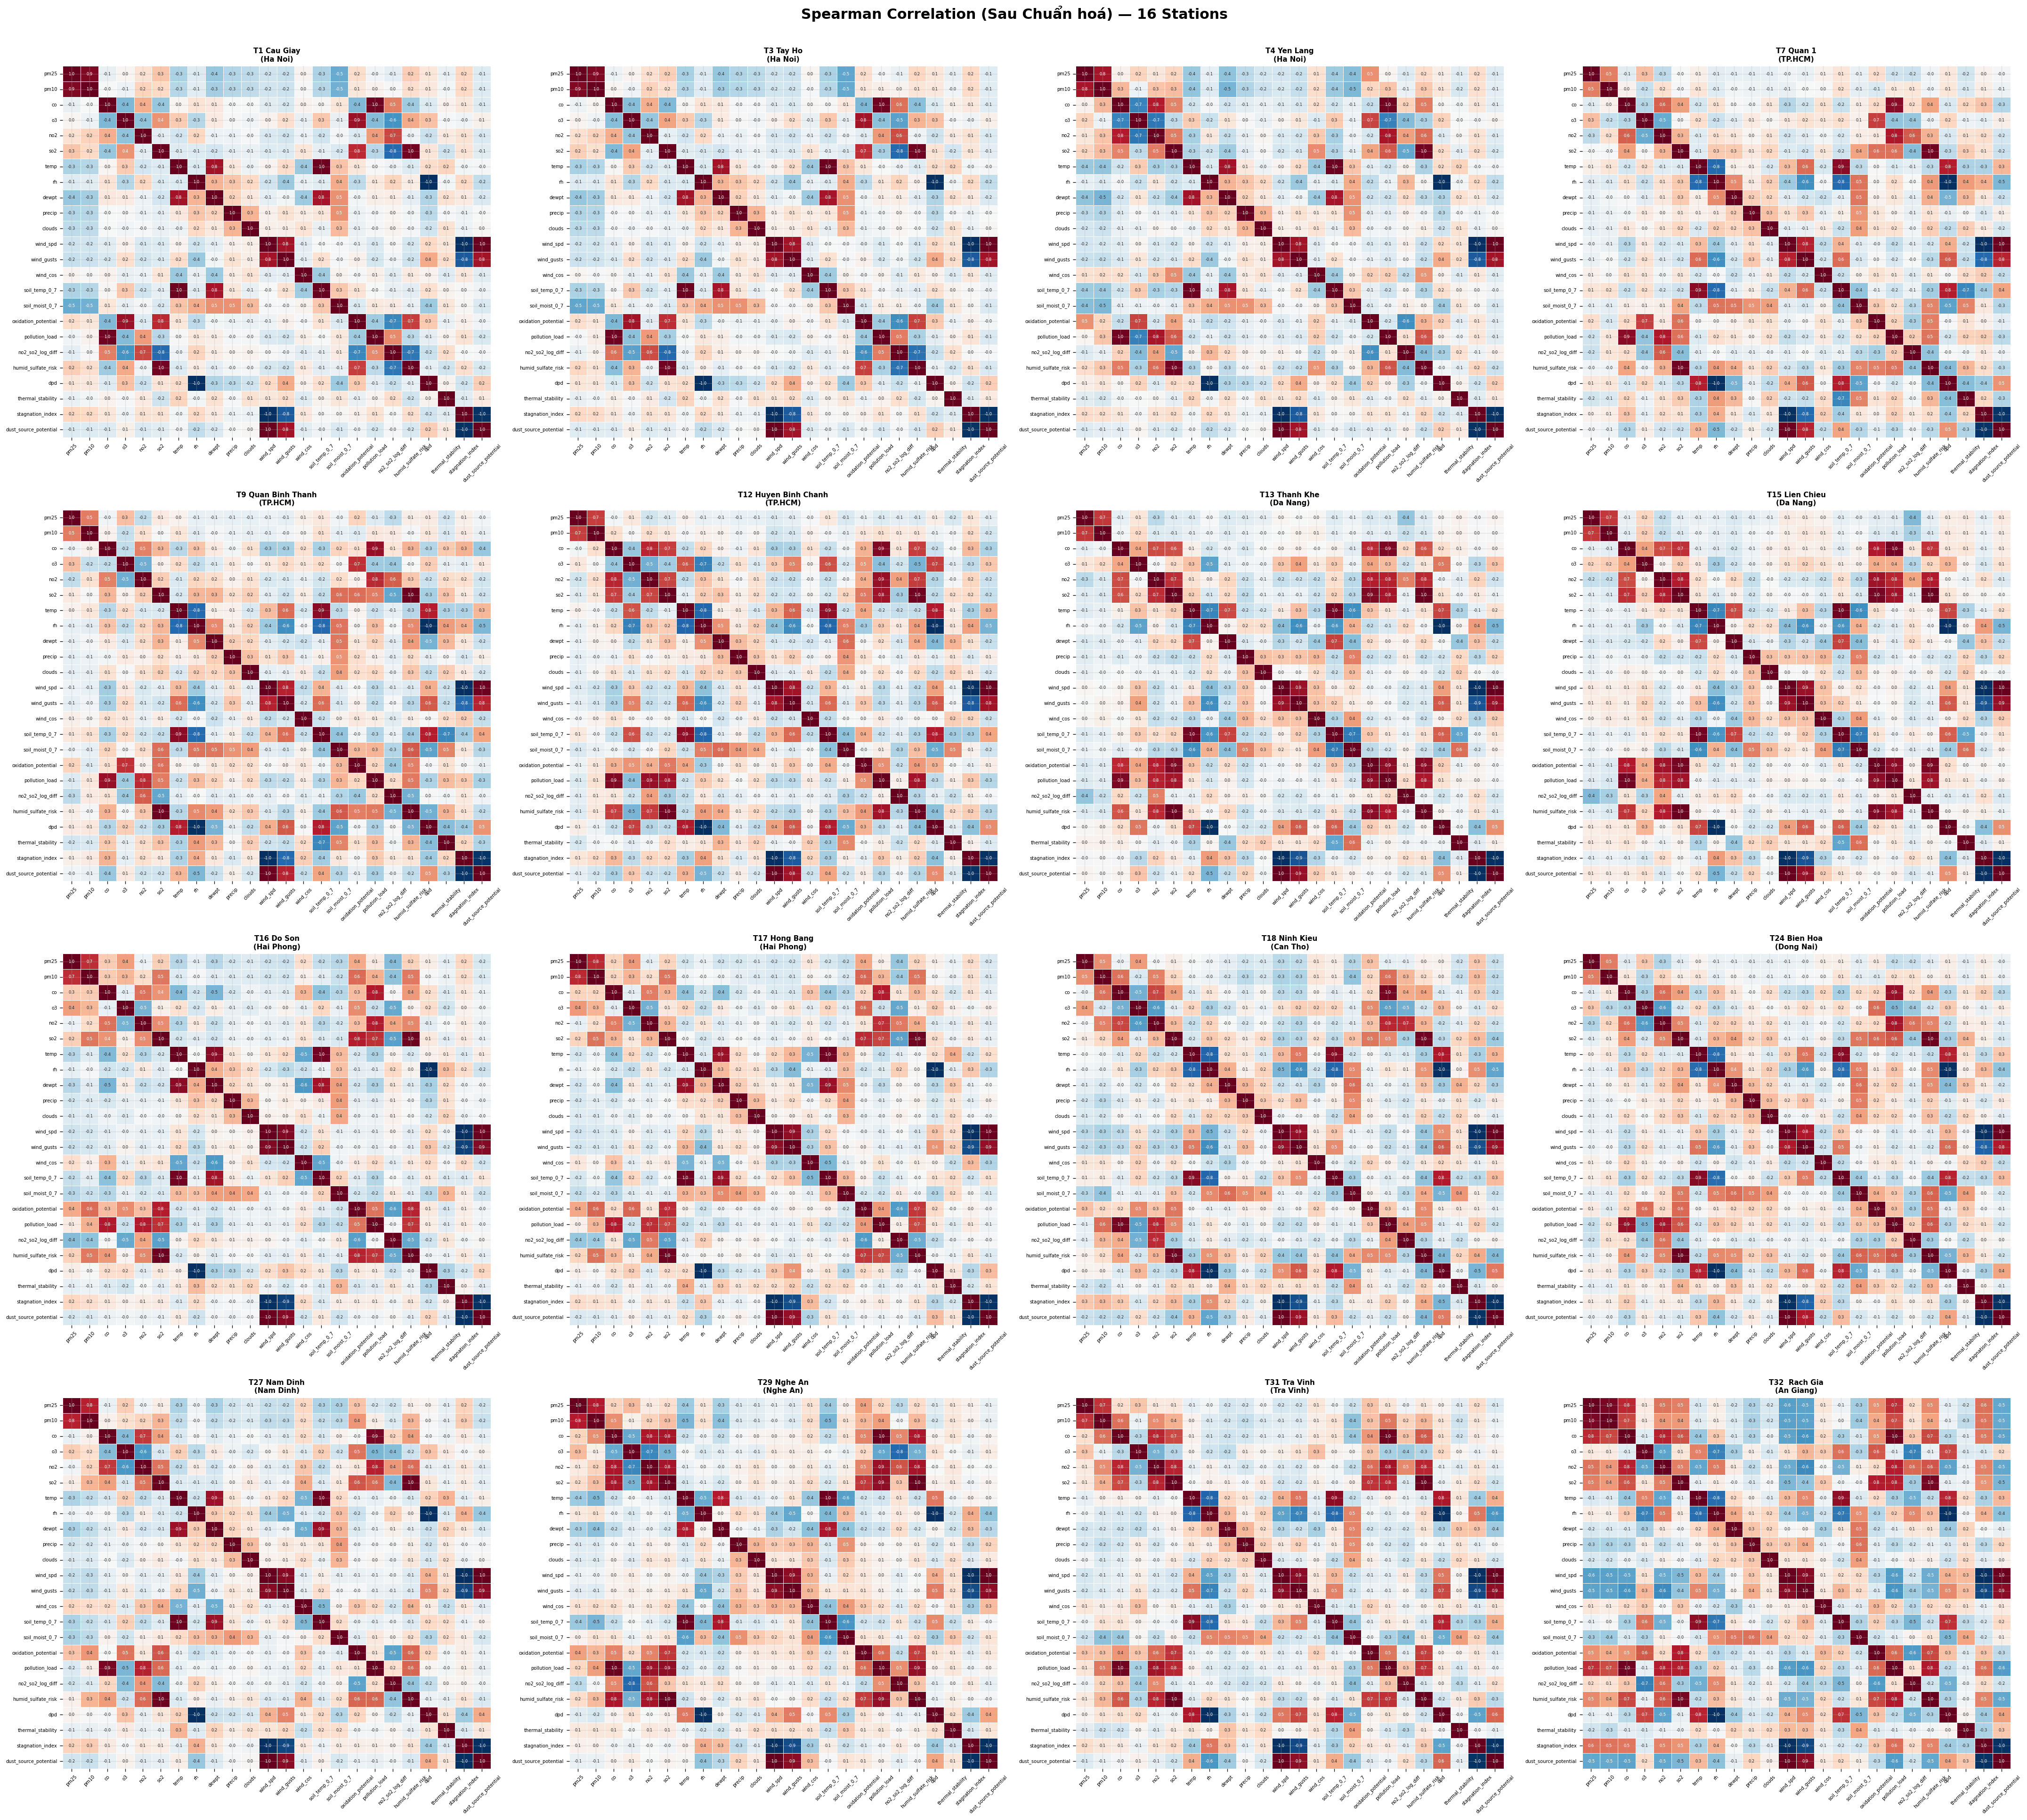

In [10]:
CORR_COLS = [c for c in ALL_SCALED if c in norm_dfs[0].columns and c != 'wind_sin']

fig, axes = plt.subplots(4, 4, figsize=(36, 32))
axes = axes.flatten()

for i, (df, meta) in enumerate(zip(norm_dfs, norm_meta)):
    ax = axes[i]
    cols = [c for c in CORR_COLS if c in df.columns]
    corr = df[cols].corr(method='spearman')
    sns.heatmap(corr, ax=ax, annot=True, fmt='.1f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                linewidths=0.3, annot_kws={'size':5}, cbar=False)
    ax.set_title(f"T{meta['station_id']} {meta['district']}\n({meta['province']})",
                 fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=6)
    ax.tick_params(axis='y', rotation=0,  labelsize=6)

fig.suptitle('Spearman Correlation (Sau Chuẩn hoá) — 16 Stations',
             fontsize=18, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('norm_corr_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. QQ Plots — Kiểm tra phân phối sau chuẩn hoá có gần Gaussian không

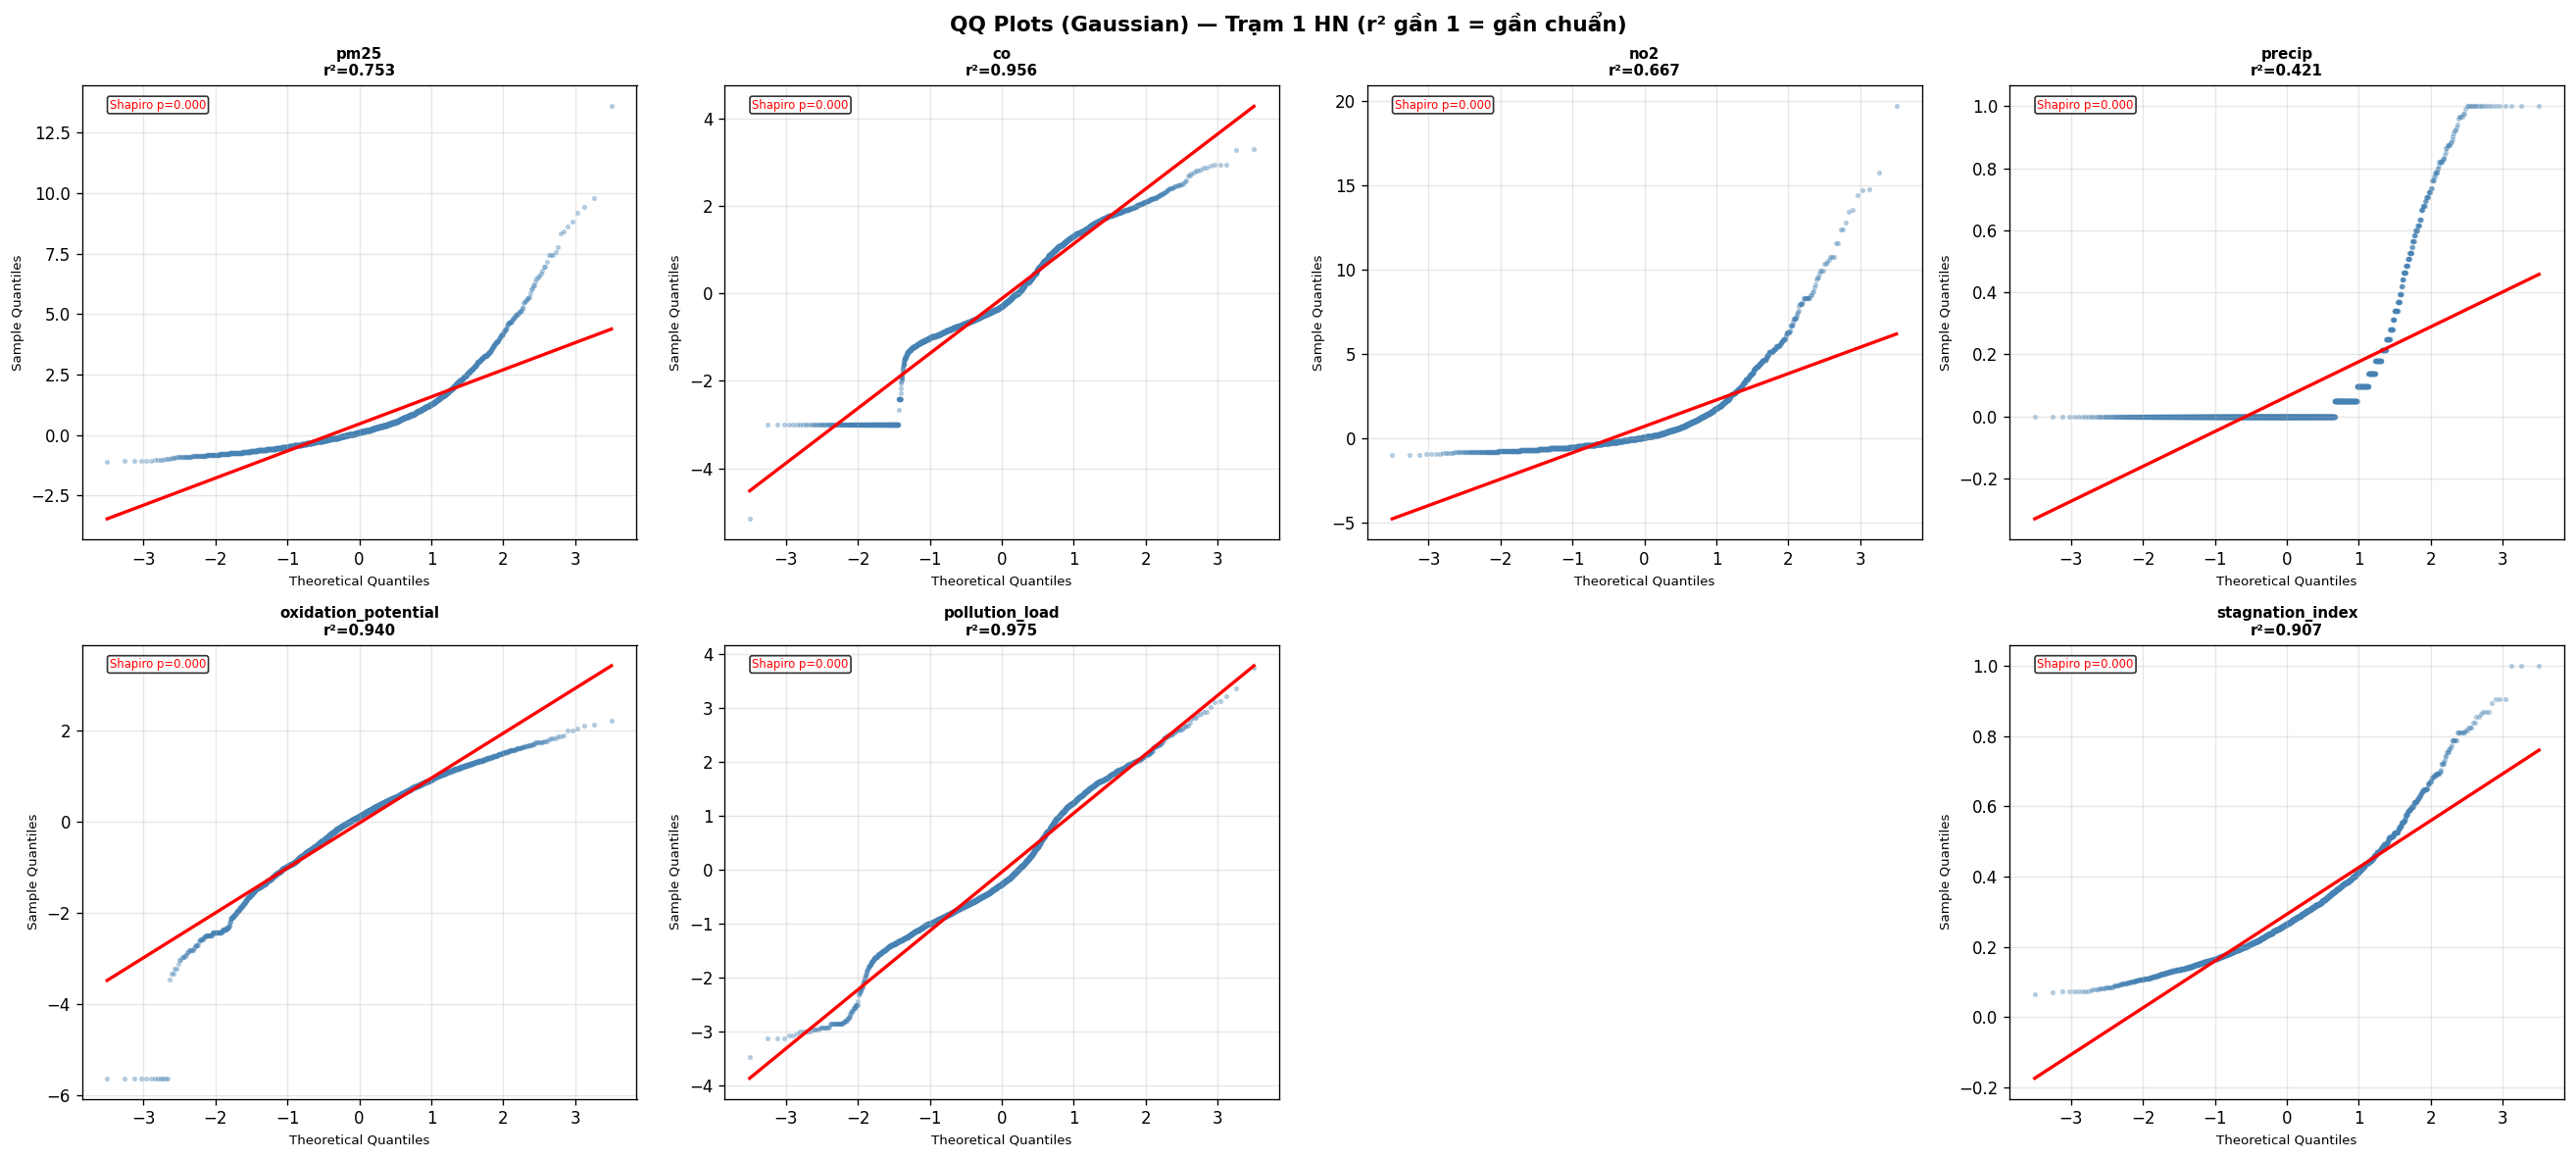

In [11]:
from scipy import stats

CHECK_COLS = ['pm25','co','no2','precip','oxidation_potential',
              'pollution_load','no2_so2_ratio','stagnation_index']

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()
df_ref = norm_dfs[0]   # Trạm 1 - HN Cau Giay

for i, col in enumerate(CHECK_COLS):
    ax = axes[i]
    if col not in df_ref.columns:
        ax.set_visible(False); continue

    vals = df_ref[col].dropna().values
    sample = np.random.choice(vals, min(3000, len(vals)), replace=False)
    (osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
    ax.scatter(osm, osr, alpha=0.3, s=5, color='steelblue')
    ax.plot(osm, slope * np.array(osm) + intercept, color='red', lw=2)
    ax.set_title(f'{col}\nr²={r**2:.3f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Theoretical Quantiles', fontsize=8)
    ax.set_ylabel('Sample Quantiles', fontsize=8)
    # Thêm Shapiro-Wilk trên subset nhỏ
    if len(sample) >= 20:
        sub = sample[:500] if len(sample) > 500 else sample
        _, p = stats.shapiro(sub)
        ax.text(0.05, 0.95, f'Shapiro p={p:.3f}',
                transform=ax.transAxes, fontsize=7,
                color='green' if p > 0.05 else 'red',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.8))

fig.suptitle('QQ Plots (Gaussian) — Trạm 1 HN (r² gần 1 = gần chuẩn)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('norm_qq_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Train / Val / Test — Kiểm tra phân phối PM2.5 không bị shift

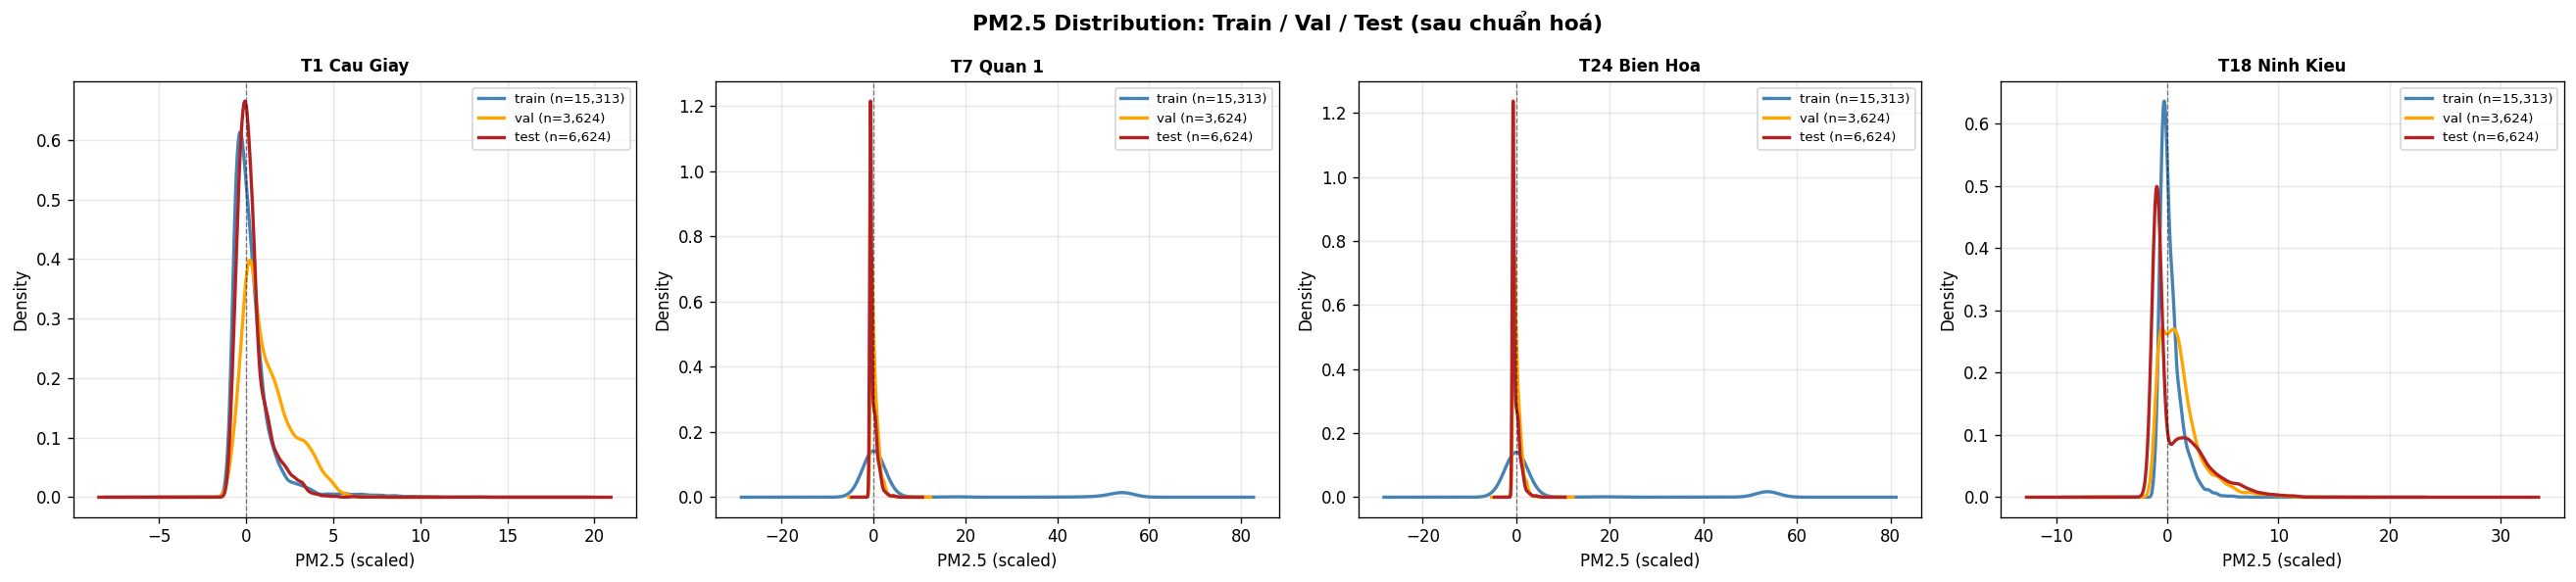


PM2.5 stats per split (Tram 1 - HN):
         count   mean    std    min    25%    50%    75%     max
split                                                           
test    6624.0  0.301  0.932 -1.118 -0.290  0.076  0.560  13.592
train  15313.0  0.325  1.296 -1.118 -0.408  0.000  0.592  12.882
val     3624.0  1.212  1.409 -0.989  0.140  0.818  2.014   7.140


In [12]:
SPLIT_STATIONS = [1, 7, 24, 18]   # HN, HCM, Bien Hoa, Can Tho
SPLIT_COLORS   = {'train':'steelblue','val':'orange','test':'firebrick'}

fig, axes = plt.subplots(1, len(SPLIT_STATIONS), figsize=(22, 5))

for ax, sid in zip(axes, SPLIT_STATIONS):
    df = gdf(sid)
    meta = norm_meta[_sid2i[sid]]
    for split, color in SPLIT_COLORS.items():
        vals = df[df['split'] == split]['pm25'].dropna()
        if len(vals) > 10:
            vals.plot.kde(ax=ax, color=color, lw=2,
                          label=f'{split} (n={len(vals):,})')
    ax.set_title(f'T{sid} {meta["district"]}', fontsize=10, fontweight='bold')
    ax.set_xlabel('PM2.5 (scaled)'); ax.legend(fontsize=8)
    ax.axvline(0, color='black', lw=0.8, ls='--', alpha=0.5)

fig.suptitle('PM2.5 Distribution: Train / Val / Test (sau chuẩn hoá)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('norm_split_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

# Summary table
print('\nPM2.5 stats per split (Tram 1 - HN):')
df1 = gdf(1)
print(df1.groupby('split')['pm25'].describe().round(3))